# Modality-Level Shapley Values by Ambiguity

**Purpose**: Compute Shapley values for each modality (Behavior, Physio, Gaze, EEG) separately for each ambiguity level (Low, Medium, High).

**Key Question**: Does the relative contribution of EEG/Physio increase at high ambiguity, where behavior features are less predictive?

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from itertools import combinations
from math import factorial
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

OUTPUT_DIR = Path('../../data/results/main/shapley_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("MODALITY SHAPLEY VALUES BY AMBIGUITY LEVEL")
print("="*70)

MODALITY SHAPLEY VALUES BY AMBIGUITY LEVEL


## 1. Load Data

In [2]:
# Load features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Load EEG features
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

# Merge EEG with main dataframe
merged_df = merged_df.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

# Create ambiguity groups
merged_df['ambiguity_group'] = merged_df['ambiguity'].replace({0: 'Low', 3: 'Medium', 6: 'High'})

print(f"Total trials: {len(merged_df)}")
print(f"Subjects: {merged_df['subject_id'].nunique()}")
print(f"\nAmbiguity distribution:")
print(merged_df['ambiguity_group'].value_counts())
print(f"\nFeature counts:")
print(f"  Behavior: {len(behavior_cols)}")
print(f"  Physio: {len(physio_cols)}")
print(f"  Gaze: {len(gaze_cols)}")
print(f"  EEG: {len(eeg_cols)}")

Total trials: 9365
Subjects: 80

Ambiguity distribution:
ambiguity_group
Low       3143
Medium    3121
High      3101
Name: count, dtype: int64

Feature counts:
  Behavior: 11
  Physio: 13
  Gaze: 20
  EEG: 16


## 2. Define Shapley Functions

In [3]:
def evaluate_coalition(modalities_to_use, modality_data, y, subjects,
                       n_estimators=100, max_depth=5, random_state=42):
    """
    Evaluate accuracy of a coalition of modalities using LOSO CV.
    """
    if len(modalities_to_use) == 0:
        return 0.5
    
    X = np.hstack([modality_data[m] for m in modalities_to_use])
    
    logo = LeaveOneGroupOut()
    subject_accs = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        subject_accs.append(accuracy_score(y_test, y_pred))
    
    return np.mean(subject_accs)


def compute_all_coalition_values(modality_data, y, subjects, verbose=True):
    """
    Compute accuracy for all possible coalitions of modalities.
    """
    modality_names = list(modality_data.keys())
    n_modalities = len(modality_names)
    coalition_values = {}
    
    coalition_values[frozenset()] = 0.5
    
    total_coalitions = 2**n_modalities - 1
    evaluated = 0
    
    for r in range(1, n_modalities + 1):
        for combo in combinations(modality_names, r):
            coalition = frozenset(combo)
            if verbose:
                evaluated += 1
                print(f"  [{evaluated}/{total_coalitions}] {set(combo)}")
            
            acc = evaluate_coalition(list(combo), modality_data, y, subjects)
            coalition_values[coalition] = acc
            
            if verbose:
                print(f"      -> Accuracy: {acc:.4f}")
    
    return coalition_values


def compute_shapley_values(modality_data, coalition_values):
    """
    Compute Shapley values from coalition values.
    """
    modality_names = list(modality_data.keys())
    n = len(modality_names)
    shapley_values = {}
    
    for modality in modality_names:
        shapley_value = 0.0
        other_modalities = [m for m in modality_names if m != modality]
        
        for r in range(len(other_modalities) + 1):
            for combo in combinations(other_modalities, r):
                S = frozenset(combo)
                S_with_i = S | {modality}
                
                v_S = coalition_values[S]
                v_S_with_i = coalition_values[S_with_i]
                marginal = v_S_with_i - v_S
                
                s = len(S)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                
                shapley_value += weight * marginal
        
        shapley_values[modality] = shapley_value
    
    return shapley_values

## 3. Compute Shapley Values for Each Ambiguity Level

In [4]:
ambiguity_results = {}
ambiguity_coalitions = {}

for amb_level in ['Low', 'Medium', 'High']:
    print(f"\n{'='*70}")
    print(f"AMBIGUITY: {amb_level.upper()}")
    print(f"{'='*70}")
    
    # Filter data for this ambiguity level
    amb_df = merged_df[merged_df['ambiguity_group'] == amb_level].copy()
    
    print(f"Trials: {len(amb_df)}")
    print(f"Subjects: {amb_df['subject_id'].nunique()}")
    
    # Prepare feature matrices
    imputer = SimpleImputer(strategy='mean')
    
    X_behavior = imputer.fit_transform(amb_df[behavior_cols])
    X_physio = imputer.fit_transform(amb_df[physio_cols])
    X_gaze = imputer.fit_transform(amb_df[gaze_cols])
    X_eeg = imputer.fit_transform(amb_df[eeg_cols])
    
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    modality_data = {
        'Behavior': X_behavior,
        'Physio': X_physio,
        'Gaze': X_gaze,
        'EEG': X_eeg
    }
    
    # Compute coalition values
    print(f"\nComputing coalition values...")
    coalition_values = compute_all_coalition_values(modality_data, y, subjects, verbose=True)
    ambiguity_coalitions[amb_level] = coalition_values
    
    # Compute Shapley values
    shapley_values = compute_shapley_values(modality_data, coalition_values)
    ambiguity_results[amb_level] = shapley_values
    
    # Print results
    print(f"\nShapley values for {amb_level} ambiguity:")
    total = sum(shapley_values.values())
    for mod, val in sorted(shapley_values.items(), key=lambda x: -x[1]):
        pct = 100 * val / total if total > 0 else 0
        print(f"  {mod}: {val:.4f} ({pct:.1f}%)")


AMBIGUITY: LOW
Trials: 3143
Subjects: 80

Computing coalition values...
  [1/15] {'Behavior'}
      -> Accuracy: 0.6539
  [2/15] {'Physio'}
      -> Accuracy: 0.5526
  [3/15] {'Gaze'}
      -> Accuracy: 0.6798
  [4/15] {'EEG'}
      -> Accuracy: 0.6956
  [5/15] {'Behavior', 'Physio'}
      -> Accuracy: 0.6633
  [6/15] {'Behavior', 'Gaze'}
      -> Accuracy: 0.7200
  [7/15] {'Behavior', 'EEG'}
      -> Accuracy: 0.6530
  [8/15] {'Gaze', 'Physio'}
      -> Accuracy: 0.6895
  [9/15] {'EEG', 'Physio'}
      -> Accuracy: 0.5828
  [10/15] {'EEG', 'Gaze'}
      -> Accuracy: 0.6843
  [11/15] {'Behavior', 'Gaze', 'Physio'}
      -> Accuracy: 0.7288
  [12/15] {'Behavior', 'EEG', 'Physio'}
      -> Accuracy: 0.6694
  [13/15] {'EEG', 'Behavior', 'Gaze'}
      -> Accuracy: 0.7061
  [14/15] {'EEG', 'Gaze', 'Physio'}
      -> Accuracy: 0.7040
  [15/15] {'EEG', 'Behavior', 'Gaze', 'Physio'}
      -> Accuracy: 0.7291

Shapley values for Low ambiguity:
  Gaze: 0.0958 (41.8%)
  Behavior: 0.0661 (28.8%)


## 4. Compare Across Ambiguity Levels

In [5]:
# Build comparison dataframe
comparison_rows = []
modality_names = ['Behavior', 'Physio', 'Gaze', 'EEG']

for amb_level in ['Low', 'Medium', 'High']:
    shapley = ambiguity_results[amb_level]
    total = sum(shapley.values())
    
    row = {'ambiguity': amb_level}
    for mod in modality_names:
        row[f'{mod}_shapley'] = shapley[mod]
        row[f'{mod}_pct'] = 100 * shapley[mod] / total if total > 0 else 0
    
    # Add full coalition accuracy
    row['full_accuracy'] = ambiguity_coalitions[amb_level][frozenset(modality_names)]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "="*70)
print("SHAPLEY VALUES BY AMBIGUITY LEVEL")
print("="*70)
print("\nRaw Shapley values (contribution to accuracy above chance):")
print(comparison_df[['ambiguity'] + [f'{m}_shapley' for m in modality_names]].to_string(index=False))

print("\nNormalized Shapley values (%):")
print(comparison_df[['ambiguity'] + [f'{m}_pct' for m in modality_names]].to_string(index=False))

print("\nFull model accuracy by ambiguity:")
print(comparison_df[['ambiguity', 'full_accuracy']].to_string(index=False))


SHAPLEY VALUES BY AMBIGUITY LEVEL

Raw Shapley values (contribution to accuracy above chance):
ambiguity  Behavior_shapley  Physio_shapley  Gaze_shapley  EEG_shapley
      Low          0.066064        0.014849      0.095840     0.052350
   Medium          0.113290       -0.006051      0.061706     0.022634
     High          0.090396        0.019615      0.066151     0.014528

Normalized Shapley values (%):
ambiguity  Behavior_pct  Physio_pct  Gaze_pct   EEG_pct
      Low     28.835912    6.481355 41.832658 22.850075
   Medium     59.134741   -3.158368 32.208962 11.814665
     High     47.404603   10.286323 34.690305  7.618769

Full model accuracy by ambiguity:
ambiguity  full_accuracy
      Low       0.729103
   Medium       0.691579
     High       0.690690


## 5. Compare with Fusion Weights

In [6]:
# Load fusion weights for comparison
fusion_weights_path = Path('../../data/results/main/eeg_integration/fusion_models_eeg_PRE')

fusion_comparison = []
for amb in ['Low', 'Medium', 'High']:
    try:
        w_df = pd.read_csv(fusion_weights_path / f'ambiguity_group_eeg_PRE_{amb}_weights.csv')
        weights = dict(zip(w_df['Modality'], w_df['Weight']))
        
        # Map Physiology -> Physio
        if 'Physiology' in weights:
            weights['Physio'] = weights.pop('Physiology')
        
        shapley = ambiguity_results[amb]
        total_shapley = sum(shapley.values())
        
        for mod in modality_names:
            fusion_comparison.append({
                'ambiguity': amb,
                'modality': mod,
                'shapley_pct': 100 * shapley[mod] / total_shapley if total_shapley > 0 else 0,
                'fusion_pct': 100 * weights.get(mod, 0)
            })
    except Exception as e:
        print(f"Could not load fusion weights for {amb}: {e}")

if fusion_comparison:
    fusion_df = pd.DataFrame(fusion_comparison)
    
    print("\n" + "="*70)
    print("SHAPLEY vs FUSION WEIGHTS BY AMBIGUITY")
    print("="*70)
    
    for amb in ['Low', 'Medium', 'High']:
        print(f"\n{amb} Ambiguity:")
        amb_data = fusion_df[fusion_df['ambiguity'] == amb]
        print(amb_data[['modality', 'shapley_pct', 'fusion_pct']].to_string(index=False))


SHAPLEY vs FUSION WEIGHTS BY AMBIGUITY

Low Ambiguity:
modality  shapley_pct  fusion_pct
Behavior    28.835912   60.539575
  Physio     6.481355    0.638076
    Gaze    41.832658   38.353072
     EEG    22.850075    0.469277

Medium Ambiguity:
modality  shapley_pct  fusion_pct
Behavior    59.134741   85.691314
  Physio    -3.158368    0.536237
    Gaze    32.208962   13.435117
     EEG    11.814665    0.337333

High Ambiguity:
modality  shapley_pct  fusion_pct
Behavior    47.404603   64.270915
  Physio    10.286323    3.039821
    Gaze    34.690305   32.136392
     EEG     7.618769    0.552871


## 6. Visualization

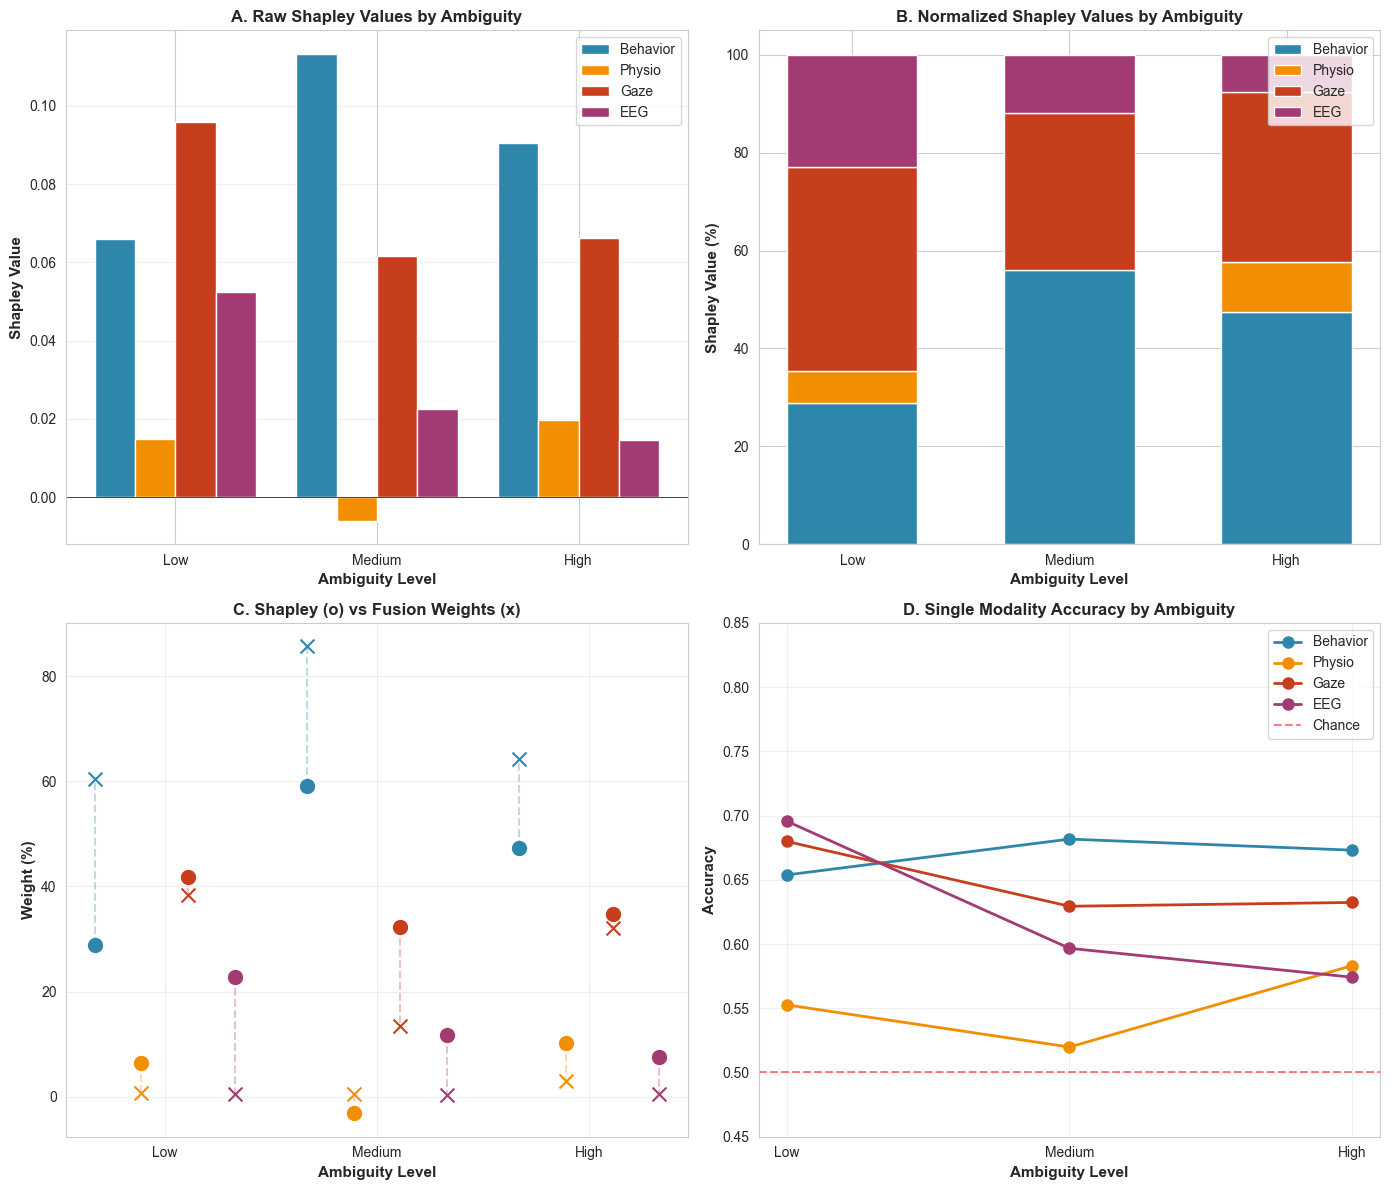

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = {'Behavior': '#2E86AB', 'Physio': '#F18F01', 'Gaze': '#C73E1D', 'EEG': '#A23B72'}

# 1. Raw Shapley values by ambiguity
ax1 = axes[0, 0]
x = np.arange(3)
width = 0.2

for i, mod in enumerate(modality_names):
    vals = [ambiguity_results[amb][mod] for amb in ['Low', 'Medium', 'High']]
    ax1.bar(x + (i - 1.5) * width, vals, width, label=mod, color=colors[mod])

ax1.set_xticks(x)
ax1.set_xticklabels(['Low', 'Medium', 'High'])
ax1.set_xlabel('Ambiguity Level', fontweight='bold')
ax1.set_ylabel('Shapley Value', fontweight='bold')
ax1.set_title('A. Raw Shapley Values by Ambiguity', fontweight='bold')
ax1.legend()
ax1.axhline(0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Normalized Shapley values (stacked bar)
ax2 = axes[0, 1]
bottom = np.zeros(3)

for mod in modality_names:
    vals = [comparison_df[comparison_df['ambiguity'] == amb][f'{mod}_pct'].values[0] 
            for amb in ['Low', 'Medium', 'High']]
    ax2.bar(x, vals, width=0.6, bottom=bottom, label=mod, color=colors[mod])
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(['Low', 'Medium', 'High'])
ax2.set_xlabel('Ambiguity Level', fontweight='bold')
ax2.set_ylabel('Shapley Value (%)', fontweight='bold')
ax2.set_title('B. Normalized Shapley Values by Ambiguity', fontweight='bold')
ax2.legend(loc='upper right')
ax2.set_ylim([0, 105])

# 3. Shapley vs Fusion weights comparison
ax3 = axes[1, 0]
if fusion_comparison:
    # Plot for each modality across ambiguity levels
    bar_width = 0.35
    amb_positions = {'Low': 0, 'Medium': 1, 'High': 2}
    
    for i, mod in enumerate(modality_names):
        mod_data = fusion_df[fusion_df['modality'] == mod]
        x_pos = np.arange(3) + i * 0.22 - 0.33
        
        shapley_vals = [mod_data[mod_data['ambiguity'] == amb]['shapley_pct'].values[0] 
                        for amb in ['Low', 'Medium', 'High']]
        fusion_vals = [mod_data[mod_data['ambiguity'] == amb]['fusion_pct'].values[0] 
                       for amb in ['Low', 'Medium', 'High']]
        
        ax3.scatter(x_pos, shapley_vals, marker='o', s=100, color=colors[mod], label=f'{mod} (Shapley)' if i == 0 else '')
        ax3.scatter(x_pos, fusion_vals, marker='x', s=100, color=colors[mod], label=f'{mod} (Fusion)' if i == 0 else '')
        
        # Connect with lines
        for j in range(3):
            ax3.plot([x_pos[j], x_pos[j]], [shapley_vals[j], fusion_vals[j]], 
                    color=colors[mod], alpha=0.3, linestyle='--')
    
    ax3.set_xticks([0, 1, 2])
    ax3.set_xticklabels(['Low', 'Medium', 'High'])
    ax3.set_xlabel('Ambiguity Level', fontweight='bold')
    ax3.set_ylabel('Weight (%)', fontweight='bold')
    ax3.set_title('C. Shapley (o) vs Fusion Weights (x)', fontweight='bold')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Fusion weights not available', ha='center', va='center', transform=ax3.transAxes)

# 4. Coalition accuracies comparison
ax4 = axes[1, 1]
single_mod_accs = {}
for amb in ['Low', 'Medium', 'High']:
    single_mod_accs[amb] = {}
    for mod in modality_names:
        single_mod_accs[amb][mod] = ambiguity_coalitions[amb][frozenset([mod])]

x = np.arange(3)
for i, mod in enumerate(modality_names):
    vals = [single_mod_accs[amb][mod] for amb in ['Low', 'Medium', 'High']]
    ax4.plot(x, vals, 'o-', label=mod, color=colors[mod], linewidth=2, markersize=8)

ax4.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax4.set_xticks(x)
ax4.set_xticklabels(['Low', 'Medium', 'High'])
ax4.set_xlabel('Ambiguity Level', fontweight='bold')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('D. Single Modality Accuracy by Ambiguity', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0.45, 0.85])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shapley_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Results

In [8]:
# Save main comparison
comparison_df.to_csv(OUTPUT_DIR / 'shapley_by_ambiguity.csv', index=False)

# Save coalition values for each ambiguity level
for amb in ['Low', 'Medium', 'High']:
    coalition_df = pd.DataFrame([
        {'coalition': ', '.join(sorted(k)) if k else '(empty)', 
         'n_modalities': len(k),
         'accuracy': v}
        for k, v in ambiguity_coalitions[amb].items()
    ]).sort_values(['n_modalities', 'accuracy'], ascending=[True, False])
    coalition_df.to_csv(OUTPUT_DIR / f'coalition_accuracies_{amb.lower()}_ambiguity.csv', index=False)

# Save Shapley vs Fusion comparison
if fusion_comparison:
    fusion_df.to_csv(OUTPUT_DIR / 'shapley_vs_fusion_by_ambiguity.csv', index=False)

print(f"\nResults saved to: {OUTPUT_DIR}/")


Results saved to: ../../data/results/main/shapley_analysis/


## 8. Summary

In [9]:
print("\n" + "="*70)
print("SUMMARY: SHAPLEY VALUES BY AMBIGUITY")
print("="*70)

print("\nKey Question: Does the relative contribution of EEG/Physio increase at high ambiguity?")

print("\nNormalized Shapley Values (%):")
print(f"{'Modality':<12} {'Low':>10} {'Medium':>10} {'High':>10} {'Change (H-L)':>12}")
print("-" * 56)

for mod in modality_names:
    low = comparison_df[comparison_df['ambiguity'] == 'Low'][f'{mod}_pct'].values[0]
    med = comparison_df[comparison_df['ambiguity'] == 'Medium'][f'{mod}_pct'].values[0]
    high = comparison_df[comparison_df['ambiguity'] == 'High'][f'{mod}_pct'].values[0]
    change = high - low
    print(f"{mod:<12} {low:>10.1f} {med:>10.1f} {high:>10.1f} {change:>+12.1f}")

print("\nSingle Modality Accuracy:")
print(f"{'Modality':<12} {'Low':>10} {'Medium':>10} {'High':>10}")
print("-" * 44)

for mod in modality_names:
    low = single_mod_accs['Low'][mod]
    med = single_mod_accs['Medium'][mod]
    high = single_mod_accs['High'][mod]
    print(f"{mod:<12} {low:>10.3f} {med:>10.3f} {high:>10.3f}")


SUMMARY: SHAPLEY VALUES BY AMBIGUITY

Key Question: Does the relative contribution of EEG/Physio increase at high ambiguity?

Normalized Shapley Values (%):
Modality            Low     Medium       High Change (H-L)
--------------------------------------------------------
Behavior           28.8       59.1       47.4        +18.6
Physio              6.5       -3.2       10.3         +3.8
Gaze               41.8       32.2       34.7         -7.1
EEG                22.9       11.8        7.6        -15.2

Single Modality Accuracy:
Modality            Low     Medium       High
--------------------------------------------
Behavior          0.654      0.682      0.673
Physio            0.553      0.520      0.583
Gaze              0.680      0.629      0.632
EEG               0.696      0.597      0.574
